<a href="https://colab.research.google.com/github/rll/deepul/blob/master/homeworks/hw1/hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Started

## Overview
This semester, all homeworks will be conducted through Google Colab notebooks. All code for the homework assignment will be written and run in this notebook. Running in Colab will automatically provide a GPU, but you may also run this notebook locally by following [these instructions](https://research.google.com/colaboratory/local-runtimes.html) if you wish to use your own GPU.

You will save images in the notebooks to use and fill out a given LaTeX template which will be submitted to Gradescope, along with your notebook code.

## Using Colab
On the left-hand side, you can click the different icons to see a Table of Contents of the assignment, as well as local files accessible through the notebook.

Make sure to go to **Runtime -> Change runtime type** and select **GPU** as the hardware accelerator. This allows you to use a GPU. Run the cells below to get started on the assignment. Note that a session is open for a maximum of 12 hours, and using too much GPU compute may result in restricted access for a short period of time. Please start the homework early so you have ample time to work.

**If you load this notebook by clicking "Open in Colab" from github, you will need to save it to your own Google Drive to keep your work.**

## General Tips
In each homework problem, you will implement autoregressive models and run it on various datasets. Oftentime you will run it on two datasets (dataset 1 and dataset 2). In these cases, the expected outputs for dataset 1 are already provided to help as a sanity check.

Feel free to print whatever output (e.g. debugging code, training code, etc) you want, as the graded submission will be the submitted pdf with images.

After you complete the assignment, download all of the images outputted in the results/ folder and upload them to the figure folder in the given latex template.

There is a lot of freedom in this homework to design write and design your own models. Hyperparameters are given as a guide to show what worked for us, but feel free to explore and use what you find is best!

Run the cells below to download and load up the starter code.

In [ ]:
!if [ -d deepul ]; then rm -Rf deepul; fi
!git clone https://github.com/rll/deepul.git
!unzip -qq deepul/homeworks/hw1/data/hw1_data.zip -d deepul/homeworks/hw1/data/
!pip install ./deepul

Cloning into 'deepul'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 270 (delta 51), reused 32 (delta 32), pack-reused 188 (from 2)
Receiving objects: 100% (270/270), 94.71 MiB | 14.68 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Processing ./deepul
  Preparing metadata (setup.py) ... done
  Created wheel for deepul: filename=deepul-0.1.0-py3-none-any.whl size=22739 sha256=14e49369bcc7171e084a73e7ec8d6c4028458148c6fe2ec067018f04221a264d
  Stored in directory: /tmp/pip-ephem-wheel-cache-iv0w_2e1/wheels/ef/ca/e6/838f85393ab50f0d590acc4f5cfa805863e523ebaee1b400c4
Successfully built deepul
  Attempting uninstall: deepul
    Found existing installation: deepul 0.1.0
    Uninstalling deepul-0.1.0:
      Successfully uninstalled deepul-0.1.0


In [ ]:
import numpy as np
from deepul.hw1_helper import (
    # Q1
    visualize_q1_data,
    q1_sample_data_1,
    q1_sample_data_2,
    q1_save_results,
    # Q2
    q2a_save_results,
    q2b_save_results,
    visualize_q2a_data,
    visualize_q2b_data,
    # Q3
    q3ab_save_results,
    q3c_save_results,
    # Q4
    q4a_save_results,
    q4b_save_results,
    # Q5
    visualize_q5_data,
    q5a_save_results,
    # Q6
    visualize_q6_data,
    q6a_save_results,
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import math
import numpy as np
import importlib
from dataclasses import dataclass

from train import *

# import autoregressive
# importlib.reload(autoregressive)
from autoregressive import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
torch.set_default_device(device)

print(f'{torch.__version__=}')
print(f'{device=}')

torch.__version__='2.8.0+cu126'
device='cuda'


# Question 1: 1D Data

In this question, we will train simple generative models on discrete 1D data.

Execute the cell below to visualize our datasets

Dataset 1


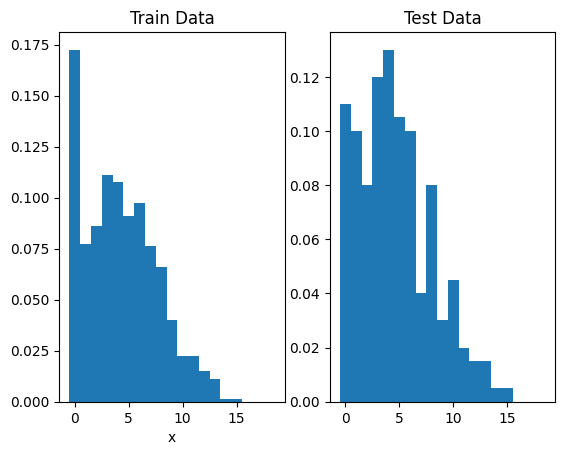

Dataset 2


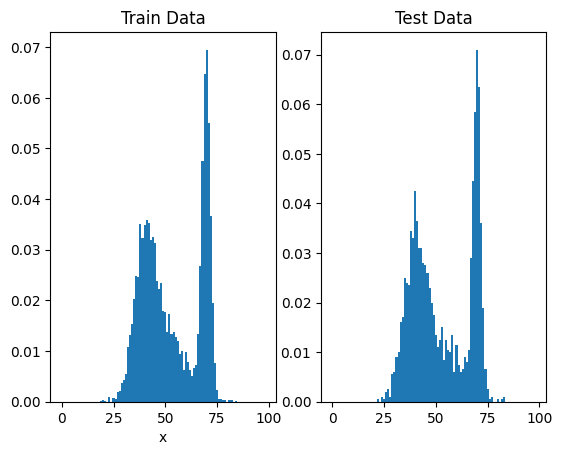

In [ ]:
visualize_q1_data(dset_type=1)
visualize_q1_data(dset_type=2)

## Part (a) Fitting a Histogram

Let $\theta = (\theta_0, \dots, \theta_{d-1}) \in \mathbb{R}^{d}$ and define the model $p_\theta(x) = \frac{e^{\theta_x}}{\sum_{x'}e^{\theta_{x'}}}$

Fit $p_\theta$ with maximum likelihood via stochastic gradient descent on the training set, using $\theta$ initialized to zero. Use your favorite version of stochastic gradient descent, and optimize your hyperparameters on a validation set of your choice.

**You will provide these deliverables**


1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. Plot the model probabilities in a bar graph with $\{0,\dots,d-1\}$ on the x-axis and a real number in $[0,1]$ on the y-axis.




Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.

In [ ]:
def q1_a(train_data, test_data, d, dset_id):
    """
    train_data: An (n_train,) numpy array of integers in {0, ..., d-1}
    test_data: An (n_test,) numpy array of integers in {0, .., d-1}
    d: The number of possible discrete values for random variable x
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
                used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (d,) of model probabilities
    """
    # set hyperparameters
    if dset_id == 1:
        lr, m, num_epochs, batch_size = 0.3, 0.9, 5, 64
    elif dset_id == 2:
        lr, m, num_epochs, batch_size = 0.1, 0.9, 5, 64

    model = Histogram(d)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=m)

    train_loader = DataLoader(train_data, batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = [], []
    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=num_epochs)

    return np.array(train_loss_history), np.array(test_loss_history), model.prob().cpu().numpy()

### Results

Once you've implemented `q1_a`, execute the cells below to visualize and save your results



initial loss: 3.022832930088043
epoch 1: 2.611786127090454
epoch 2: 2.516036629676819
epoch 3: 2.498341202735901
epoch 4: 2.513848841190338
epoch 5: 2.4884133338928223
Final Test Loss: 2.4884


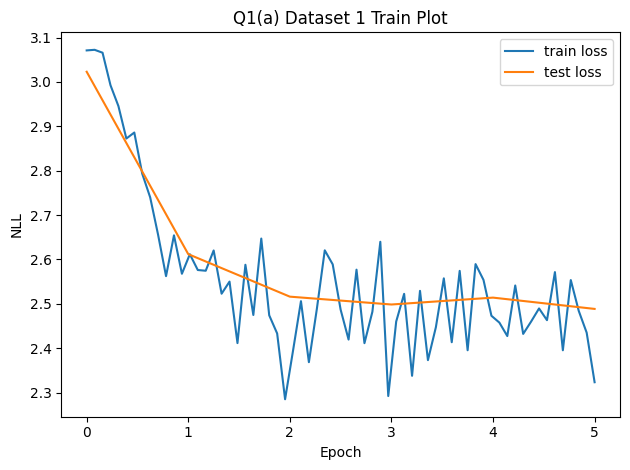

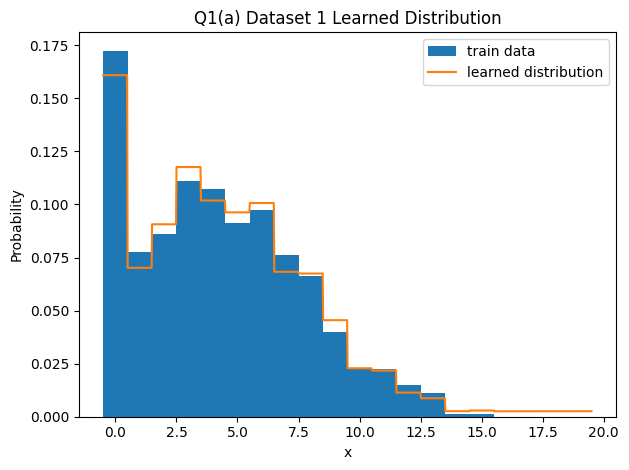

In [ ]:
q1_save_results(1, 'a', q1_a)

initial loss: 4.605871871113777
epoch 1: 3.8157490342855453
epoch 2: 3.7366566583514214
epoch 3: 3.710530713200569
epoch 4: 3.6968395188450813
epoch 5: 3.687191218137741
Final Test Loss: 3.6872


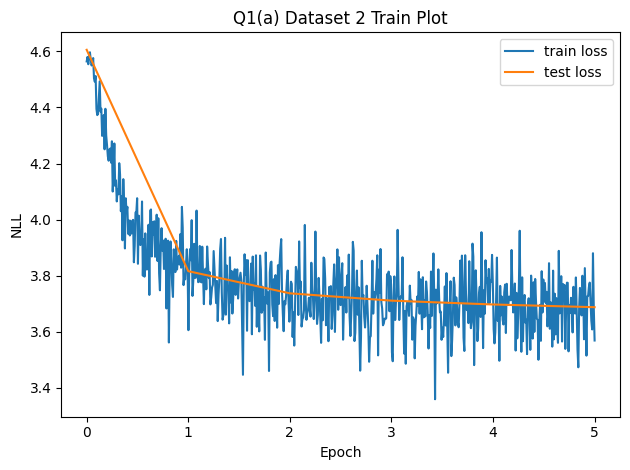

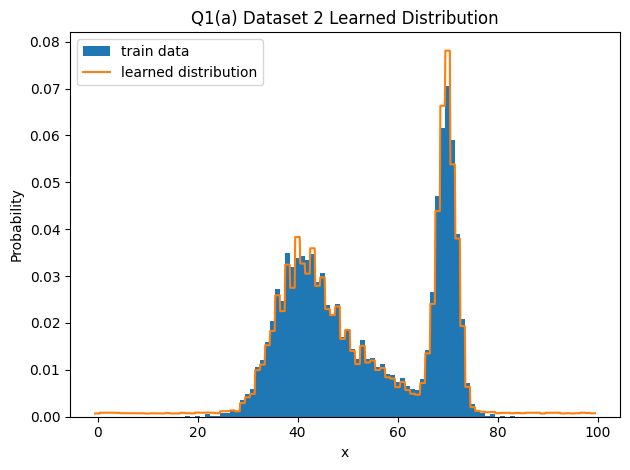

In [ ]:
q1_save_results(2, 'a', q1_a)

## Part (b) Fitting Discretized Mixture of Logistics

Let us model $p_\theta(x)$ as a **discretized** mixture of 4 logistics such that $p_\theta(x) = \sum_{i=1}^4 \pi_i[\sigma((x+0.5 - \mu_i)/s_i) - \sigma((x-0.5-\mu_i)/s_i)]$

For the edge case of when $x = 0$, we replace $x-0.5$ by $-\infty$, and for $x = 99$, we replace $x+0.5$ by $\infty$.

You may find the [PixelCNN++](https://arxiv.org/abs/1701.05517) helpful for more information on discretized mixture of logistics.

**Provide the same set of corresponding deliverables as part (a)**

Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.

In [ ]:
def q1_b(train_data, test_data, d, dset_id):
    """
    train_data: An (n_train,) numpy array of integers in {0, ..., d-1}
    test_data: An (n_test,) numpy array of integers in {0, .., d-1}
    d: The number of possible discrete values for random variable x
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (d,) of model probabilities
    """
    if dset_id == 1:
        lr, m, num_epochs, batch_size = 0.3, 0.9, 10, 128
    elif dset_id == 2:
        lr, m, num_epochs, batch_size = 0.1, 0.9, 20, 128

    model = DiscretizedMixtureOfLogistics(d)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_data, batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = [], []
    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=num_epochs)

    return np.array(train_loss_history), np.array(test_loss_history), np.array(model.prob().cpu())

### Results

Once you've implemented `q1_b`, execute the cells below to visualize and save your results



initial loss: 3.0671749114990234
epoch 1: 2.6020734310150146
epoch 2: 2.561717987060547
epoch 3: 2.574495792388916
epoch 4: 2.5745766162872314
epoch 5: 2.5694812536239624
epoch 6: 2.572302460670471
epoch 7: 2.5627719163894653
epoch 8: 2.5625473260879517
epoch 9: 2.558969497680664
epoch 10: 2.5732206106185913
Final Test Loss: 2.5732


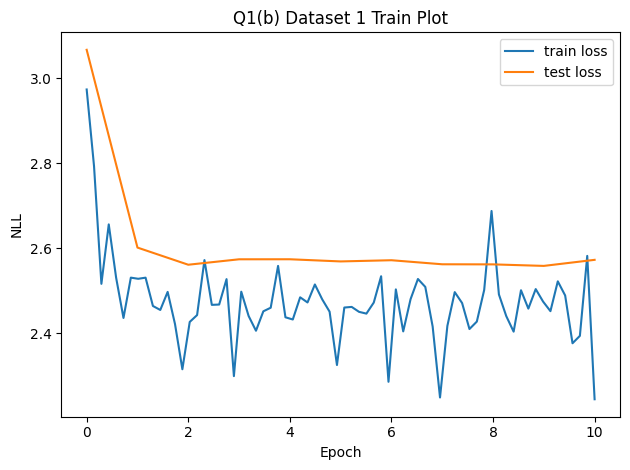

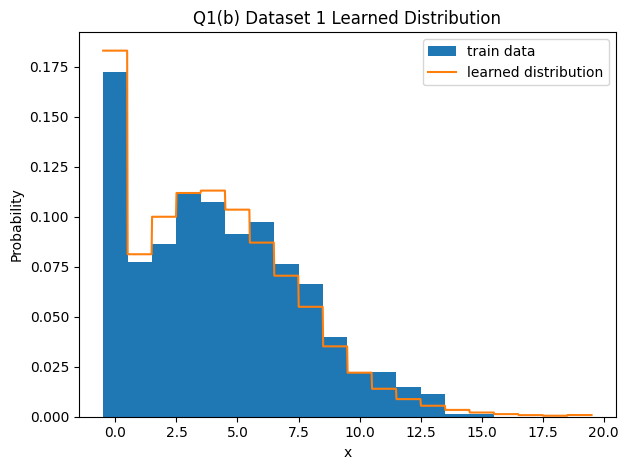

In [ ]:
q1_save_results(1, 'b', q1_b)

initial loss: 9.071533024311066
epoch 1: 4.530215919017792
epoch 2: 4.395733952522278
epoch 3: 4.260414868593216
epoch 4: 4.168523579835892
epoch 5: 4.1302410662174225
epoch 6: 4.1187704205513
epoch 7: 4.116429448127747
epoch 8: 4.116546928882599
epoch 9: 4.11426904797554
epoch 10: 4.088527709245682
epoch 11: 3.759392097592354
epoch 12: 3.694869503378868
epoch 13: 3.6892108768224716
epoch 14: 3.690159186720848
epoch 15: 3.692602187395096
epoch 16: 3.6868228018283844
epoch 17: 3.6885858923196793
epoch 18: 3.693444550037384
epoch 19: 3.6996432691812515
epoch 20: 3.705394685268402
Final Test Loss: 3.7054


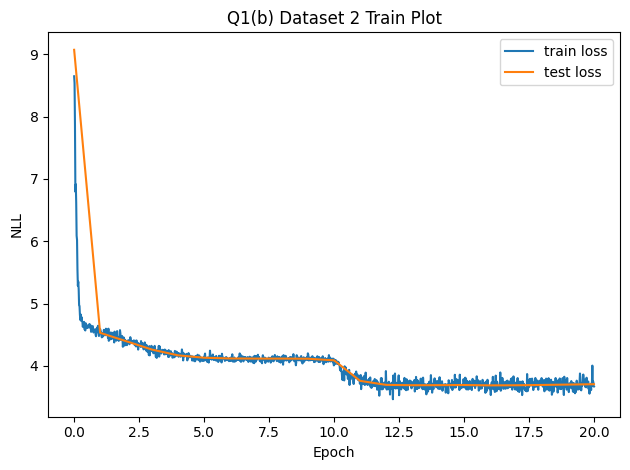

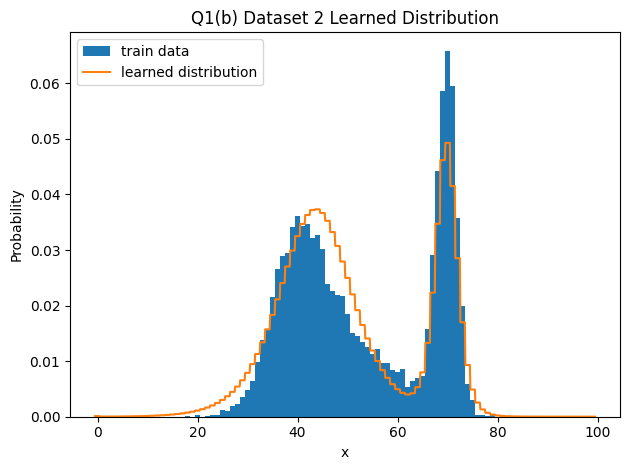

In [ ]:
q1_save_results(2, 'b', q1_b)

# Question 2 PixelCNNs

Now, you will train more powerful PixelCNN models on the shapes dataset and MNIST. In addition, we will extend to modeling colored datasets.

Run the cell below to visualize the two datasets binary datasets

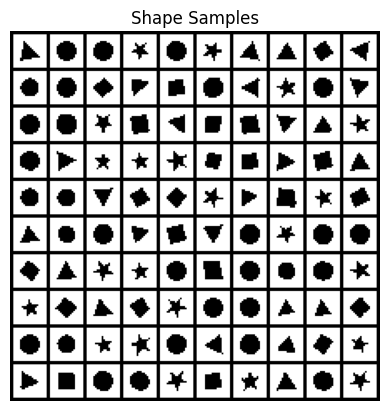

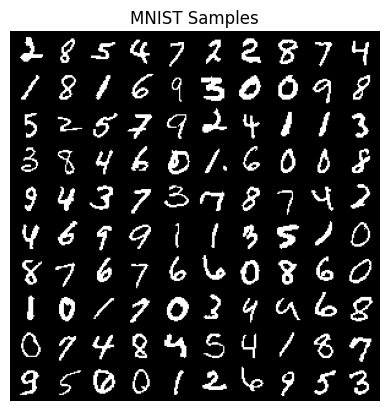

In [ ]:
visualize_q2a_data(1)
visualize_q2a_data(2)

## Part (a) PixelCNN on Shapes and MNIST
In this part, implement a simple PixelCNN architecture to model binary MNIST and shapes images (same as Q2(b), but with a PixelCNN).

We recommend the following network design:
* A $7 \times 7$ masked type A convolution
* $5$ $7 \times 7$ masked type B convolutions
* $2$ $1 \times 1$ masked type B convolutions
* Appropriate ReLU nonlinearities in-between
* 64 convolutional filters

And the following hyperparameters:
* Batch size 128
* Learning rate $10^{-3}$
* 10 epochs
* Adam Optimizer (this applies to all PixelCNN models trained in future parts)

Your model should output logits, after which you could apply a sigmoid over 1 logit, or a softmax over two logits (either is fine). It may also help to scale your input to $[-1, 1]$ before running it through the network.

Training on the shapes dataset should be quick, and MNIST should take around 10 minutes

Checkout the Paper for more details: https://arxiv.org/abs/1601.06759

**You will provide these deliverables**


1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. 100 samples from the final trained model



Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.

In [ ]:
def q2_a(train_data, test_data, image_shape, dset_id):
    """
    train_data: A (n_train, H, W, 1) uint8 numpy array of binary images with values in {0, 1}
    test_data: A (n_test, H, W, 1) uint8 numpy array of binary images with values in {0, 1}
    image_shape: (H, W), height and width of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (100, H, W, 1) of samples with values in {0, 1}
    """
    # preprocess train/test data
    train_data = train_data.reshape((-1, 1, *image_shape)).astype(np.float32)
    test_data = test_data.reshape((-1, 1, *image_shape)).astype(np.float32)

    if dset_id == 1:
        lr, num_epochs, batch_size, num_channels = 0.001, 10, 128, 64
    elif dset_id == 2:
        lr, num_epochs, batch_size, num_channels = 0.001, 10, 128, 64

    model = PixelCNNSimple(image_shape, num_channels)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_data, batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = [], []
    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=num_epochs)

    return np.array(train_loss_history), np.array(test_loss_history), np.array(model.samples(100).cpu().view(-1, *(image_shape), 1))

### Results

Once you've implemented `q2_a`, execute the cells below to visualize and save your results



initial loss: 0.7258615791797638
epoch 1: 0.16026669243971506
epoch 2: 0.13437755861216122
epoch 3: 0.11191883517636193
epoch 4: 0.09522176078624195
epoch 5: 0.08053851582937771
epoch 6: 0.07188848240507974
epoch 7: 0.0642033117926783
epoch 8: 0.05956166051328182
epoch 9: 0.055954019642538495
epoch 10: 0.05333083619674047
Final Test Loss: 0.0533


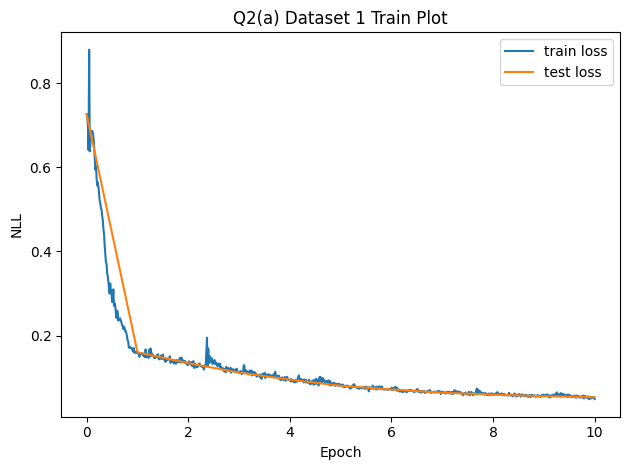

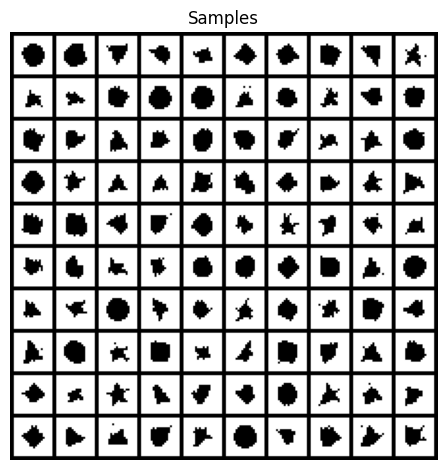

In [ ]:
q2a_save_results(1, q2_a)

initial loss: 0.686477464211138
epoch 1: 0.09044911221990103
epoch 2: 0.08548705270396004
epoch 3: 0.08365613995473596
epoch 4: 0.08255687827550912
epoch 5: 0.08356871427614478
epoch 6: 0.08079836130896702
epoch 7: 0.08105451726838003
epoch 8: 0.07988571554799623
epoch 9: 0.07918325943660133
epoch 10: 0.07893018424510956
Final Test Loss: 0.0789


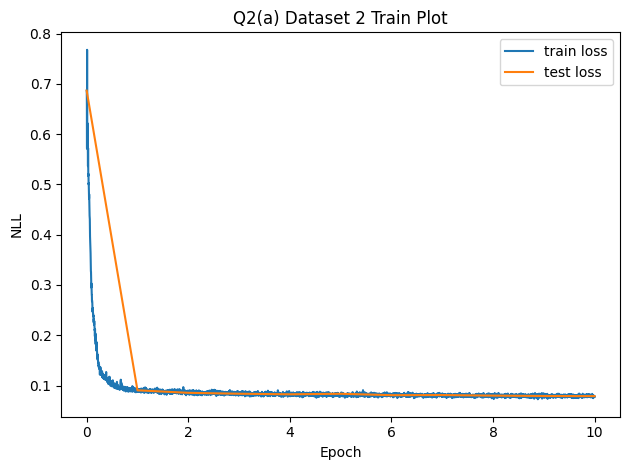

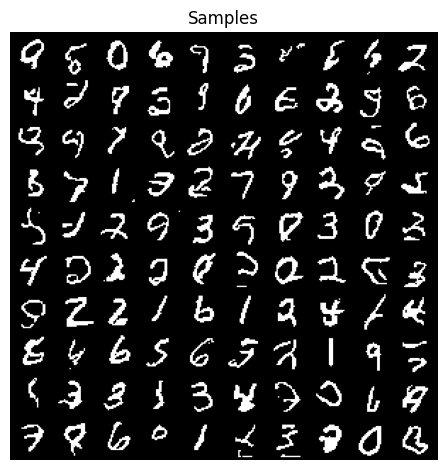

In [ ]:
q2a_save_results(2, q2_a)

## Part (b) PixelCNN on Colored Shapes and MNIST: Independent Color Channels

For the next part, we'll work with color images (shapes and MNIST). Run the cell below to visualize the dataset.

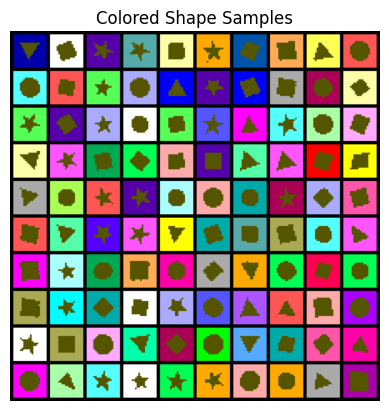

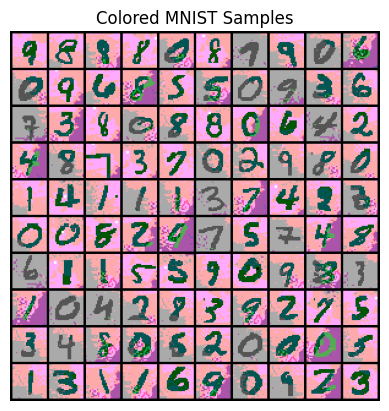

In [ ]:
visualize_q2b_data(1)
visualize_q2b_data(2)

Now, implement a PixelCNN to support RGB color channels (or augment your existing implementation). **First, implement a PixelCNN that assumes color channels as independent.** More formally, we model the following parameterized distribution:

$$p_\theta(x) = \prod_{i=1}^{HW}\prod_{c=1}^C p_\theta(x_i^c | x_{<i})$$

Here are some tips that you may find useful for designing and training these models:
* You will need a 4-way softmax for every prediction, as opposed to a 256-way softmax in the PixelCNN paper, since the dataset is quantized to two bits per color channel
* You can set the number of filters for each convolutions to 120. You can use the ReLU nonlinearity throughout.
* Use a stack of 8 residual block architecture from [Figure 5](https://arxiv.org/abs/1601.06759) but with 7 x 7 masked convolutions in the middle instead of 3 x 3 masked convolutions
* Consider using [layer normalization](https://arxiv.org/abs/1607.06450) to improve performance. However, be careful to maintain the autoregressive property.
* With a learning rate of $10^{-3}$ and a batch size of 128, it should take a few minutes to run on the shapes dataset, and about 50-60 minutes on MNIST.

**You will provide these deliverables**


1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. 100 samples from the final trained model



Fill out the function below and return the necessary arguments. Feel free to create more cells if need be.

In [ ]:
def q2_b(train_data, test_data, image_shape, dset_id):
    """
    train_data: A (n_train, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    test_data: A (n_test, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    image_shape: (H, W, C), height, width, and # of channels of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (100, H, W, C) of samples with values in {0, 1, 2, 3}
    """
    # (B, H, W, C) -> (B, C, H, W)
    train_data = np.moveaxis(train_data, -1, 1).astype(np.float32)
    test_data = np.moveaxis(test_data, -1, 1).astype(np.float32)

    if dset_id == 1:
        lr, num_epochs, batch_size, num_channels, num_layers = 0.001, 15, 128, 120, 8
    elif dset_id == 2:
        lr, num_epochs, batch_size, num_channels, num_layers = 0.001, 10, 128, 120, 8

    model = PixelCNN(image_shape, num_channels, num_layers)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_data, batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = [], []
    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=num_epochs, clip=1.0)

    samples = model.samples(100).cpu().permute(0, 2, 3, 1)

    return np.array(train_loss_history), np.array(test_loss_history), np.array(samples)

### Results

Once you've implemented `q2_b`, execute the cells below to visualize and save your results



initial loss: 1.438894636101193
epoch 1: 0.39614100754261017
epoch 2: 0.14454004251294666
epoch 3: 0.14153389549917644
epoch 4: 0.08134800961448087
epoch 5: 0.07131873692075412
epoch 6: 0.06654670068787204
epoch 7: 0.05813954594648547
epoch 8: 0.30727242926756543
epoch 9: 0.058769262602759734
epoch 10: 0.05242506362911728
epoch 11: 0.049583963532414704
epoch 12: 0.04779856144968006
epoch 13: 0.046121891484492354
epoch 14: 0.045917373357547656
epoch 15: 0.04536959591011206
Final Test Loss: 0.0454


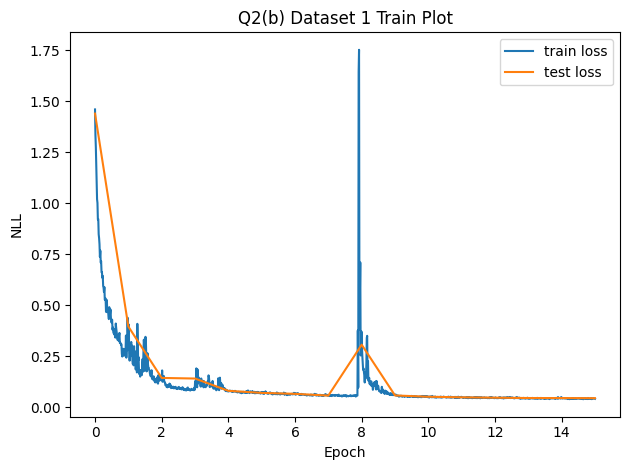

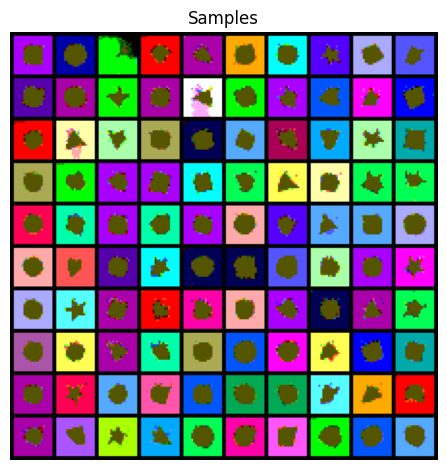

In [ ]:
q2b_save_results(1, 'b', q2_b)

initial loss: 1.420594862744778
epoch 1: 0.20300437095044535
epoch 2: 0.11198231398682051
epoch 3: 0.0964576477491403
epoch 4: 0.09281219617475438
epoch 5: 0.09068091892743413
epoch 6: 0.08786458710703669
epoch 7: 0.08609138929013964
epoch 8: 0.08366435832237895
epoch 9: 0.08275908335477491
epoch 10: 0.08165754066615165
Final Test Loss: 0.0817


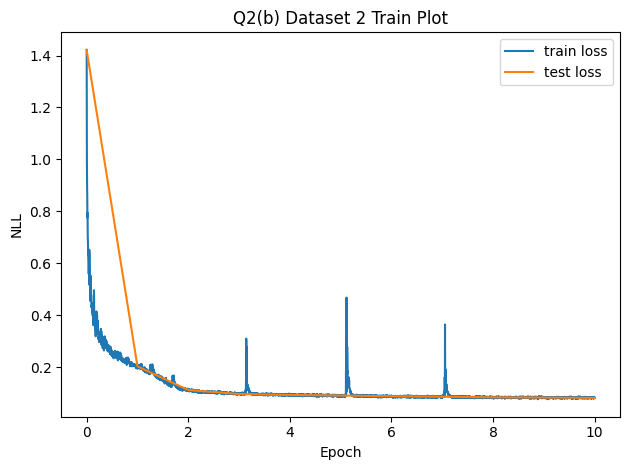

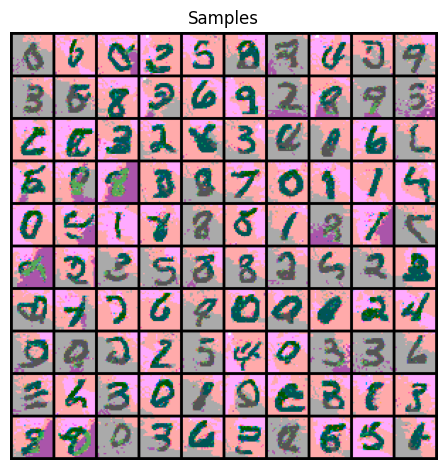

In [ ]:
q2b_save_results(2, 'b', q2_b)

# Question 3: Causal Transformer - iGPT

Now we will move onto the current most popular and widespread autoregressive model, the transformer.

## Part (a) Autoregressive Transformer on Shapes and MNIST
In this part, implement a simple Autoregressive Transformer to model binary MNIST and shapes images (same as Q2(a), but with a Transformer).

Some additional notes about your transformer implementation:
 * iGPT uses learned positional encodings. We recommend to use those here as well. However, you may also use sinusoidal positional encodings if you wish (see the [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper)
 * Autoregressive transformer always predicts the **next** token, give prior tokens. iGPT has a special **\<bos\>** or beginning of sequence token at the start of every sequence every image. Make sure to include this in your implementation as well. You can generate unconditional sample by conditioning with the **\<bos\>** token.
 * While dropout is a common feature in transformer models, you do not need to add it (but may if you wish!).
 * Prebuilt transformers exist in some frameworks (i.e. pytorch). Don't just use an off the shelf implementation as the point of the exercise is to better understand the transformer architecture. Building the transformer from the ground up (use primitives such as Linear/Dense layers, LayerNorm, GeLU, Embedding)
 * Learning rate warmup and cos learning rate decay are often used when training transformers to improve training stability and improve performance. See if this helps your model! Try 1000 steps of warmup with a cosine learning rate decay.

Paper references
* [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
* [Generative Pretraining from Pixels](https://cdn.openai.com/papers/Generative_Pretraining_from_Pixels_V2.pdf)
* [Language Models are Unsupervised Multitask Learners](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)

We recommend the following network design parameters:
* $d_{model}$: 128
* heads: 4
* layers: 2
* GeLU nonlinearities

And the following hyperparameters:
* Batch size: 64 or 32 or 16 (whichever fits in your GPU)
* Learning rate: $10^{-3}$
* 15 epochs or more
* Adam Optimizer (this applies to all Transformers models trained in future parts)

**You will provide these deliverables**

1. Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2. Report the final test set performance of your final model
3. 100 samples from the final trained model



In [ ]:
def q3_a(train_data, test_data, image_shape, dset_id):
    """
    train_data: A (n_train, H, W, 1) uint8 numpy array of color images with values in {0, 1}
    test_data: A (n_test, H, W, 1) uint8 numpy array of color images with values in {0, 1}
    image_shape: (H, W, 1), height, width, and # of channels of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (100, H, W, 1) of samples with values in {0, 1}
    """
    n_train, H, W, _ = train_data.shape
    n_test = test_data.shape[0]

    train_data = train_data.reshape(n_train, -1)
    test_data = test_data.reshape(n_test, -1)

    @dataclass
    class Config:
        num_epochs = 15
        batch_size = 32
        lr = 1e-3
        warmup_iters = 1000
        min_lr = 1e-4
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        dropout = 0.0
        num_tokens = 3

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    model = Transformer(n_tokens=Config.num_tokens, max_seq_len=H*W, n_heads=4, n_layers=2, d_model=128, dropout=Config.dropout)

    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_data, Config.batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, Config.batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=Config.num_epochs,
                                                    lr_scheduler=lr_scheduler, clip=1.0)


    return np.array(train_loss_history), np.array(test_loss_history), np.array(model.generate(100).cpu().view(-1, H, W, 1))

### Results

Once you've implemented `q3_a`, execute the cells below to visualize and save your results

initial loss: 0.5465259917661653
epoch 1: 0.08469306661727581
epoch 2: 0.0573224627168466
epoch 3: 0.04641733458595918
epoch 4: 0.04155236001767165
epoch 5: 0.04025353419970959
epoch 6: 0.03846925288333115
epoch 7: 0.03687958724479726
epoch 8: 0.036240788440860754
epoch 9: 0.034875235843954355
epoch 10: 0.03417992886446469
epoch 11: 0.03374917921445048
epoch 12: 0.0331315620544743
epoch 13: 0.03265361781132982
epoch 14: 0.03236682191226922
epoch 15: 0.03234828854019337
Final Test Loss: 0.0323


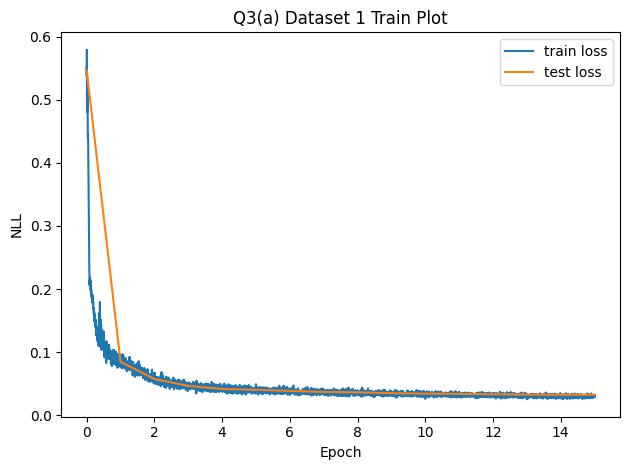

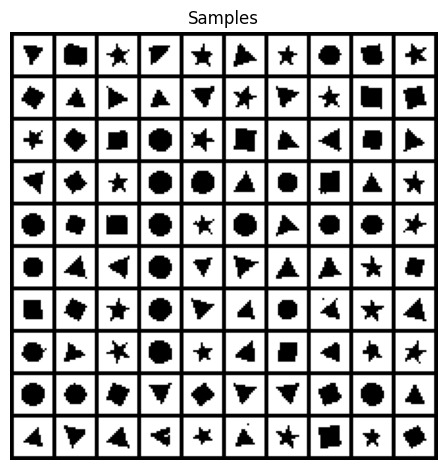

In [ ]:
q3ab_save_results(1, 'a', q3_a)

initial loss: 0.7739055867012317
epoch 1: 0.08715004959521583
epoch 2: 0.08046426381261204
epoch 3: 0.07820184988240464
epoch 4: 0.07654132694005966
epoch 5: 0.07559717865512013
epoch 6: 0.07448002452048631
epoch 7: 0.07399564333997977
epoch 8: 0.07352360348684338
epoch 9: 0.07300387476437008
epoch 10: 0.07258779993548561
epoch 11: 0.07225006303419701
epoch 12: 0.07204855300081424
epoch 13: 0.07200915969836826
epoch 14: 0.07192455295223397
epoch 15: 0.07212020448459604
Final Test Loss: 0.0721


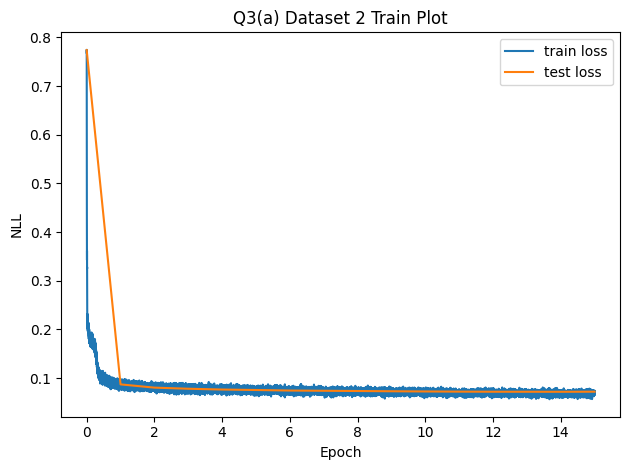

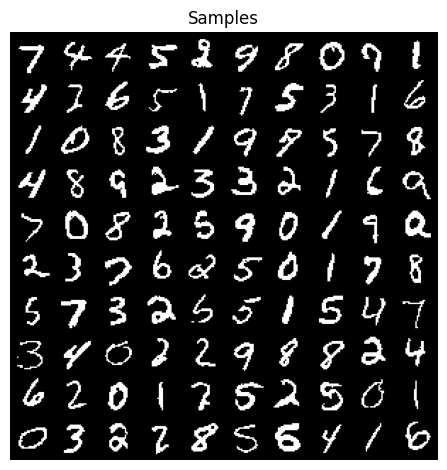

In [ ]:
torch.cuda.empty_cache()
q3ab_save_results(2, 'a', q3_a)

## Part (b) iGPT on Colored Shapes and MNIST

Now, implement an iGPT that models color. In order to reduce the length of token sequences, iGPT models each RGB pixel as a **single** token. This effectively reduces the context length from H*W*C to just H*W. iGPT does this through a k-means clustering approach. Because our images only each can only take on 4 values (2 bits) per channel, we can represent each pixel with 64 values (6 bits). Convert the dataset into an image of tokens and train iGPT on the colored shapes and MNIST dataset.

Checkout the iGPT paper for more details: [Generative Pretraining from Pixels](https://cdn.openai.com/papers/Generative_Pretraining_from_Pixels_V2.pdf)

Training times and hyperparameter settings should be the same as part (a), except train for longer (15 epochs)

**You will provide these deliverables**

1.   Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2.   Report the final test set performance of your final model
3. 100 samples from the final trained model


In [ ]:
def base_to_tokens(x: np.ndarray, base=4, channels=3):
    B = x.shape[0]
    f = base ** np.arange(0, channels)[::-1]
    return np.sum(x * f, axis=-1)

def token_to_base(x: np.ndarray, base=4, n_channels=3):
    factors = np.array([base**i for i in reversed(range(n_channels))])
    out = (x[..., np.newaxis] // factors) % base
    return out

In [ ]:
def q3_b(train_data, test_data, image_shape, dset_id):
    """
    train_data: A (n_train, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    test_data: A (n_test, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    image_shape: (H, W, C), height, width, and # of channels of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (100, H, W, C) of samples with values in {0, 1, 2, 3}
    """
    n_train, H, W, _ = train_data.shape
    n_test = test_data.shape[0]

    # preprocess data to be in correct format
    train_data = base_to_tokens(train_data)  # -> (n_train, H, W)
    train_data = train_data.reshape(n_train, -1)

    test_data = base_to_tokens(test_data)  # -> (n_train, H, W)
    test_data = test_data.reshape(n_test, -1)

    @dataclass
    class Config:
        num_epochs = 15
        batch_size = 32
        lr = 1e-3
        warmup_iters = 0
        min_lr = 1e-4
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        dropout = 0.0
        num_tokens = 3

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    model = Transformer(n_tokens=65, max_seq_len=H*W, n_heads=4, n_layers=2, d_model=128, dropout=Config.dropout)

    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_data, Config.batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, Config.batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=Config.num_epochs,
                                                    lr_scheduler=lr_scheduler, clip=1.0)

    torch.save(model.state_dict(), 'model.pt')

    return np.array(train_loss_history), np.array(test_loss_history), np.array(token_to_base(model.generate(100).cpu().view(-1, H, W)))

### Results

Once you've implemented `q3_b`, execute the cells below to visualize and save your results

initial loss: 4.333377303806603
epoch 1: 0.10064406555595128
epoch 2: 0.0805945541736082
epoch 3: 0.07303751693338367
epoch 4: 0.06764438344126052
epoch 5: 0.06292944826872636
epoch 6: 0.06214612460833915
epoch 7: 0.05939917385261109
epoch 8: 0.05896458124860804
epoch 9: 0.057083171759302734
epoch 10: 0.05625552795034774
epoch 11: 0.055364966735983574
epoch 12: 0.05508843669337584
epoch 13: 0.05463022067614481
epoch 14: 0.0542835755709638
epoch 15: 0.05408237792604358


/tmp/ipython-input-1360257331.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  out = (x[..., np.newaxis] // factors) % base


Final Test Loss: 0.0541


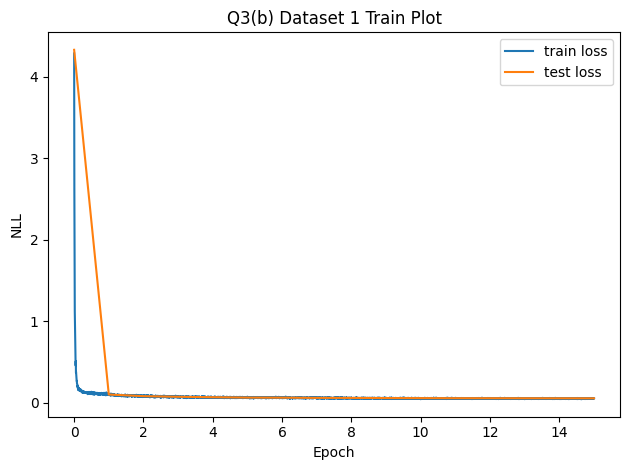

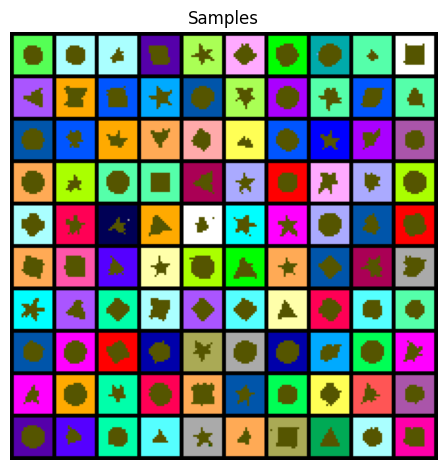

In [ ]:
torch.cuda.empty_cache()
q3ab_save_results(1, 'b', q3_b)

initial loss: 4.378835282005822
epoch 1: 0.2335349840763659
epoch 2: 0.1311725973844909
epoch 3: 0.11481700118738242
epoch 4: 0.10602735106746991
epoch 5: 0.10018812336575109
epoch 6: 0.09712800069358021
epoch 7: 0.09430003951723202
epoch 8: 0.09317340830358835
epoch 9: 0.09060185785872486
epoch 10: 0.08905275720662584
epoch 11: 0.08792166138133302
epoch 12: 0.08684179670037553
epoch 13: 0.08612564739327842
epoch 14: 0.08567409795789292
epoch 15: 0.08540050045084267


/tmp/ipython-input-1360257331.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  out = (x[..., np.newaxis] // factors) % base


Final Test Loss: 0.0854


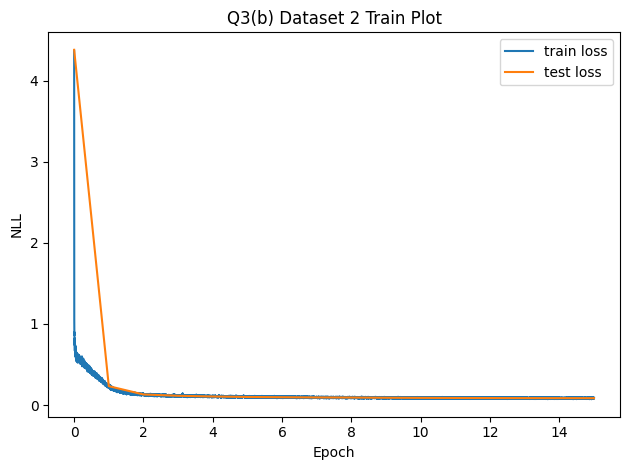

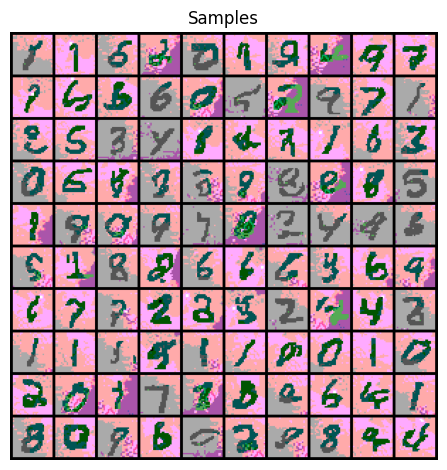

In [ ]:
torch.cuda.empty_cache()
q3ab_save_results(2, 'b', q3_b)

## Part (c) K, V Caching for Improved Inference
You may have noticed that generation from the transformer is quite slow. Part of this is just due to the autoregressive nature. However, another part is due to some computational inefficiency. At each forward pass of the model, we are performing repeat computation of the past sequence. Specifically, we can cache the key and values at the multi attention layer to more quickly predict at each step.

In self-attention, a sequence is processed by generating three vectors for each element in the sequence: a Query (Q), a Key (K), and a Value (V). These vectors are then used to compute attention scores and subsequently the output of the attention layer.
Mathematically, this can be represented as:
 * For each index $i$, compute $Q_i$, $K_i$, $V_i$ for the current element
 * Retrieve $K_{<i}$ and $V_{<i}$ from the cache (where $<i$ denotes all indices before the current one)
 * Compute the attention output using $Q_i$, $[K_{<i}, K_i]$, $[V_{<i}, V_i]$


Next implement caching for your transformer to make inference more efficient by modifying your self attention. Use caching for inference in the future problems for faster generation! (Note caching is only used during inference). You will use the same dataset as in part B, dataset 2 of this question (colored mnist). No training is required in this section, feel free to reuse the model you trained in part B, dataset 2.

**You will provide these deliverables**

1. Over the course of inference, measure the time for the forward pass over the total sequence length with and without caching.
3. 100 samples from the final trained model using the caching inference pipeline.



In [ ]:
def q3_c(train_data, test_data, image_shape, dset_id):
    """
    train_data: A (n_train, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    test_data: A (n_test, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    image_shape: (H, W, C), height, width, and # of channels of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets

    Returns
    - a (# sampling steps,) numpy array of time per sampling iteration, without caching
    - a (# sampling steps,) numpy array of time per sampling iteration, with without caching
    - a numpy array of size (100, H, C, W) of samples with values in {0, 1, 2, 3} (sample generated without caching)
    - a numpy array of size (100, H, C, W) of samples with values in {0, 1, 2, 3} (sample generated with caching)
    """
    n_train, H, W, C = train_data.shape

    model = TransformerWithKVCache(n_tokens=65, max_seq_len=H*W, n_heads=4, n_layers=2, d_model=128, dropout=0.0)

    model.load_state_dict(torch.load('model.pt'))

    time_list_no_cache, samples_no_cache = model.generate(100, use_KV_cache=False)
    time_list_no_cache = np.array(time_list_no_cache) / 1e3
    print(f'{time_list_no_cache.mean()=}')
    samples_no_cache = np.array(token_to_base(samples_no_cache.cpu().view(-1, H, W)))

    time_list_with_cache, samples_with_cache = model.generate(100, use_KV_cache=True)
    time_list_with_cache = np.array(time_list_with_cache) / 1e3
    print(f'{time_list_with_cache.mean()=}')
    samples_with_cache = np.array(token_to_base(samples_with_cache.cpu().view(-1, H, W)))

    return time_list_no_cache, time_list_with_cache, samples_no_cache, samples_with_cache

### Results

Once you've implemented `q3_c`, execute the cells below to visualize and save your results



time_list_no_cache.mean()=np.float64(0.038447029624666486)


/tmp/ipython-input-1360257331.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  out = (x[..., np.newaxis] // factors) % base


time_list_with_cache.mean()=np.float64(0.001974012080351917)


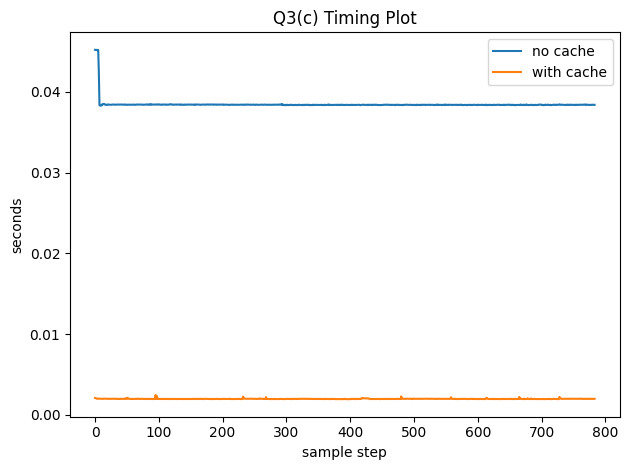

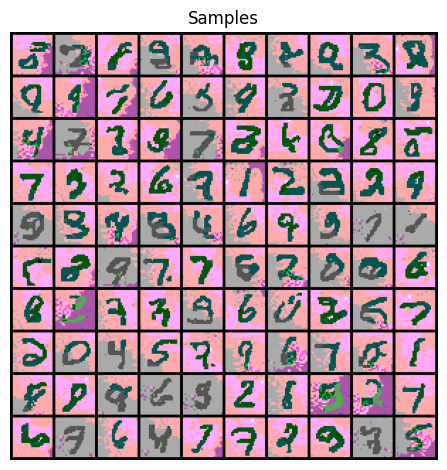

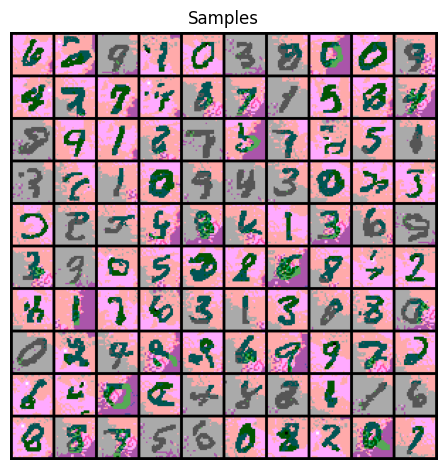

In [ ]:
q3c_save_results(2, q3_c)

# Question 4: Causal Transformer: Tokenized Images

## Image Tokenization with Vector Quanization

## Part (a) Image Quantization

Above, we implemented iGPT, which autoregressivly predicts raw pixels. Transformers have quadratic complexity in the sequence length which prevents this naive approach from scaling well to large images.

The space of natural images often contains very correlated information. This suggests we can learn a reduced representation. VQVAE is a method that does just that, learning to map images to a more compact discrete set of tokens. We will cover this method in more detail in future lectures. The only thing you need to know now is that we can learn an encoder (and corresponding decoder), which can extract a discrete representation from an image.

If you are curious, checkout the VQVAE paper to learn more: https://arxiv.org/abs/1711.00937 (we will cover this in a future lecture though!)

In this part, we provide a pre-trained VQVAE model, which consists of:
 * encoder to tokenize the images
 * the decoder to recover the image
 * a token vocabulary of VQVAE_MODEL.n_embeddings

Below is the code for loading the VQ model. Note that VQVAE encoding process is lossy, so the decoded images will not be the exact same as the input. Some blurriness in the recovered image is to be expected. The docstrings of the relevant methods you will need for the VQVAE_MODEL are provided below for your convenience.

We will use 2 colored mnist datasets in this part. The first is the same dataset used in previous parts. The second, hads a colored digit on a differently colored background. We will call these datasets Colored MNIST and Colored MNIST v2. Note that the vqvae is trained per dataset.

**You will provide these deliverables**

1. Use the provided encoder model to quantize the images then inspect the recovered images by applying the decoder for each of the two datasets

In [ ]:
# @property
# def n_embeddings(self) -> int:
#     """The size of the token vocabulary"""
#
# def quantize(self, x: np.ndarray) -> np.ndarray:
#     """Quantize an image x.
#
#     Args:
#         x (np.ndarray, dtype=int): Image to quantize. shape=(batch_size, 28, 28, 3). Values in [0, 3].
#
#     Returns:
#         np.ndarray: Quantized image. shape=(batch_size, 7, 7). Values in [0, n_embeddings]
#     """
#
# def decode(self, z_index: np.ndarray) -> np.ndarray:
#     """Decode a quantized image.
#
#     Args:
#         z_index (np.ndarray, dtype=int): Quantized image. shape=(batch_size, 7, 7). Values in [0, n_embeddings].
#
#     Returns:
#         np.ndarray: Decoded image. shape=(batch_size, 28, 28, 3). Values in [0, 3].
#     """
#

In [ ]:
def q4_a(images, vqvae):
  """
  images: (B, H, W, C), the images to pass through the encoder and decoder of the vqvae
  vqvae: a vqvae model, trained on the relevant dataset

  Returns
  - a numpy array of size (2, H, W, C) of the decoded image
  """
  print(f'{vqvae.n_embeddings=}')
  q_image = vqvae.quantize(images)  # (B, H, W, C) -> (B, 7, 7)
  autoencoded_images = vqvae.decode(q_image.cpu().numpy())  # (B, 7, 7) -> (B, H, W, C)
  print(autoencoded_images.shape)
  return autoencoded_images

vqvae.n_embeddings=1024


(2, 28, 28, 3)


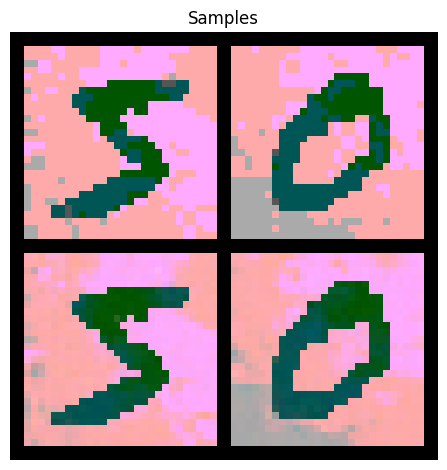

In [ ]:
q4a_save_results(1, q4_a)

vqvae.n_embeddings=1024
(2, 28, 28, 3)


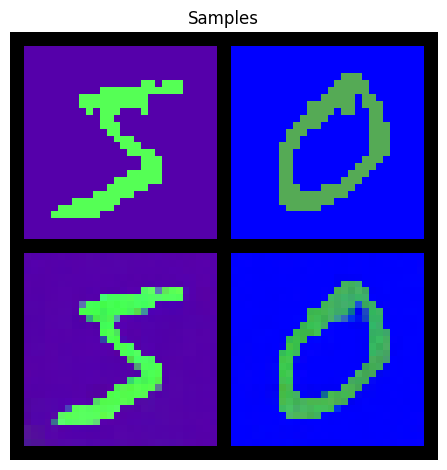

In [ ]:
q4a_save_results(2, q4_a)

## Part (b) Autoregressive Transformer on Colored Shapes and MNIST with Vector Quantization

We can use the VQVAE to tokenize an image dataset. This will result in a much smaller sequence length than the approach we tried in Question 3(b). For this part, train a transformer on the dataset tokenized by the VQVAE.

This is a simplified version of the approach used in VQGAN [VQGAN](https://arxiv.org/abs/2012.09841) -> Section 3.2: Learning the Composition of Images with Transformers (Again, we will cover this in more detail in a future lecture!)

Update the following hyperparameters:
* layers: 4 (we can train a bigger transformer now since less memory is used per input!)
* 30 epochs

**You will provide these deliverables**

1. Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2. Report the final test set performance of your final model
3. 100 samples from the final trained model

In [ ]:
def q4_b(train_data, test_data, image_shape, dset_id, vqvae):
    """
    train_data: A (n_train, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    test_data: A (n_test, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    image_shape: (H, W, C), height, width, and # of channels of the image
    dset_id: An identifying number of which dataset is given (1 or 2). Most likely
            used to set different hyperparameters for different datasets
    vqvae: a vqvae model, trained on dataset dset_id

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a numpy array of size (100, H, C, W) of samples with values in {0, 1, 2, 3}
    """
    @dataclass
    class Config:
        num_epochs = 15
        batch_size = 32
        lr = 1e-3
        warmup_iters = 0
        min_lr = 1e-4
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        dropout = 0.0

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    n_train, H, W, _ = train_data.shape
    n_test = test_data.shape[0]
    H_t, W_t = 7, 7  # tokenized shape

    train_data = tokenize_data_set(vqvae, train_data, H_t, W_t)
    test_data = tokenize_data_set(vqvae, test_data, H_t, W_t)

    train_data, test_data = train_data.astype(int), test_data.astype(int)


    model = Transformer(n_tokens=1025, max_seq_len=H_t*W_t, n_heads=4, n_layers=2, d_model=128, dropout=Config.dropout)

    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_data, Config.batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_data, Config.batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=Config.num_epochs,
                                                    lr_scheduler=lr_scheduler, clip=1.0)

    torch.save(model.state_dict(), 'model_q4.pt')

    samples = vqvae.decode(model.generate(100).cpu().numpy().reshape(-1, H_t, W_t))

    return np.array(train_loss_history), np.array(test_loss_history), samples

### Results

Once you've implemented `q4_b`, execute the cells below to visualize and save your results



In [ ]:
torch.cuda.empty_cache()

initial loss: 7.073000108091215
epoch 1: 3.7430731450406887
epoch 2: 3.343612016580356
epoch 3: 3.189533049306169
epoch 4: 3.119605069724135
epoch 5: 3.0617116960092856
epoch 6: 3.0251129686642
epoch 7: 2.9922335947664402
epoch 8: 2.9786015318605465
epoch 9: 2.965911296229012
epoch 10: 2.954409800398464
epoch 11: 2.9510411949584276
epoch 12: 2.9527745917201424
epoch 13: 2.95336235064668
epoch 14: 2.959518012147361
epoch 15: 2.964090512583431
Final Test Loss: 2.9641


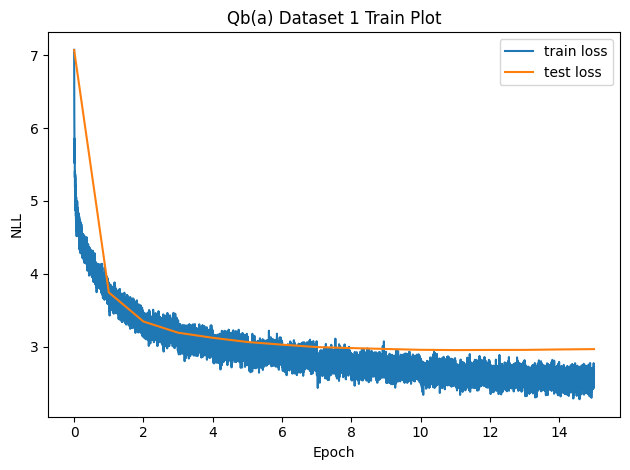

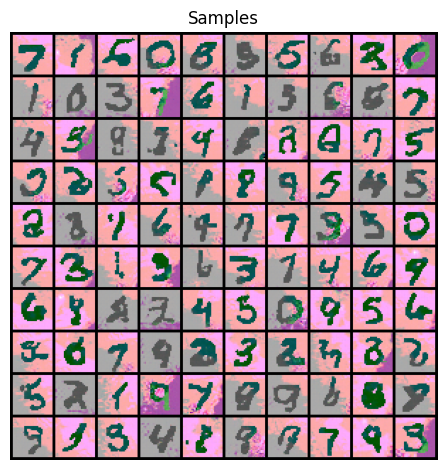

In [ ]:
q4b_save_results(1, q4_b)

initial loss: 7.093394600926116
epoch 1: 3.414438930944132
epoch 2: 3.2340202407715037
epoch 3: 3.146591669454361
epoch 4: 3.089852374963486
epoch 5: 3.057332548470543
epoch 6: 3.0292497732387944
epoch 7: 3.0120100319956817
epoch 8: 2.9943879640902193
epoch 9: 2.987596124886705
epoch 10: 2.9827070921754686
epoch 11: 2.9850295785897836
epoch 12: 2.9851093909230095
epoch 13: 2.9903092369103965
epoch 14: 2.9940176368140565
epoch 15: 3.0002522491418517
Final Test Loss: 3.0003


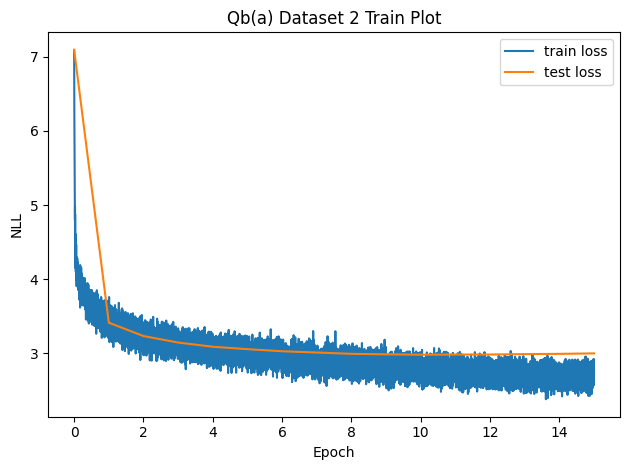

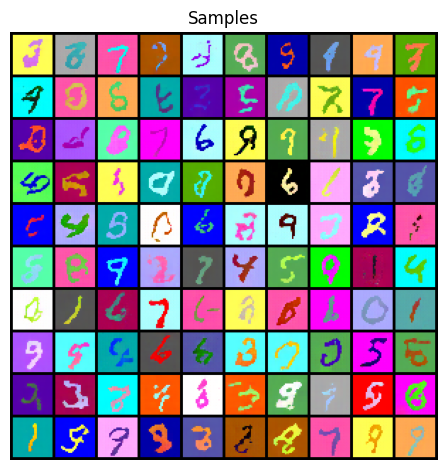

In [ ]:
q4b_save_results(2, q4_b)

# Question 5: Causal Transformer: Text

Now lets consider text! You are probably already fimilar with autoregressive transformers for text, now more commonly known as Large Language Modesl (LLMs).
We will now implement a simplified version.

We will be detailing with a [small poetry dataset](https://huggingface.co/datasets/merve/poetry). See some of the data below.

In [ ]:
data = visualize_q5_data()

Sample 1
Stephen Spender, "Song" from New Collected Poems, published by Faber. Copyright  2004. Reprinted by kind permission of the Estate of Stephen Spender.
--------------------------------------------------------------------------------

Sample 2
Farewell, false love, the oracle of lies,
A mortal foe and enemy to rest,
An envious boy, from whom all cares arise,
A bastard vile, a beast with rage possessed,
A way of error, a temple full of treason,
In all effects contrary unto reason.

A poisoned serpent covered all with flowers,
Mother of sighs, and murderer of repose,
A sea of sorrows whence are drawn such showers
As moisture lend to every grief that grows;
A school of guile, a net of deep deceit,
A gilded hook that holds a poisoned bait.

A fortress foiled, which reason did defend,
A siren song, a fever of the mind,
A maze wherein affection finds no end,
A raging cloud that runs before the wind,
A substance like the shadow of the sun,
A goal of grief for which the wisest run.

A qu

## Part (a) Modeling Text
Train a transformer on the poetry dataset.

Data Preprocessing:
* We will use a simple method to tokenize the data. We will convert each unique character into a token. (Current LLMs use more sophisticated tokenizers, most commonly, [byte-pair encoding](https://huggingface.co/learn/nlp-course/chapter6/5?fw=pt))
* Previously we have leveraged a **\<bos\>** as part of the model, just like iGPT. For text, we may not always sample a sequence that starts at the beginning. Instead, we will add the **\<bos\>** token to the beginning of every sequence in the dataset, and remove the **\<bos\>** token from the model.
* Another problem is that the model must know when to stop sampling. This is done by appending an **\<eos\>**, or end of sequence token at the end of every sequence in the dataset.
* We can now convert the sequence into subsequences of size context_length, for training!

We recommend the following hyperparameters:
* Sequence length: 128
* 5 epochs

**You will provide these deliverables**

1. Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2. Report the final test set performance of your final model
3. Provide **5 unconditional samples** of **128 characters** showcasing the model text generation capabilities (text samples should stop after **\<eos\>**. Text after **\<eos\>** can be removed in post processing)

In [ ]:
# q5_a output uses arial font which does not exist on colab
from matplotlib import font_manager
import shutil, os

src = font_manager.findfont("DejaVu Sans")
print("Using font at:", src)

shutil.copy(src, "arial.ttf")

assert os.path.exists("arial.ttf")

Using font at: /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf


In [ ]:
import torch.utils.data as data
def q5_a(train_text, test_text):
    """
    train_text: list[str] Train text sequences.
    test_text: list[str] Test text sequences.

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a list of 5 (str), 5 generated samples from the model.
    """
    preprocessor = Preprocessor(train_text)
    X_train, Y_train = preprocessor.preprocess(train_text)
    X_test, Y_test = preprocessor.preprocess(train_text)

    train_set = data.TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
    test_set = data.TensorDataset(torch.tensor(X_test), torch.tensor(Y_test))

    @dataclass
    class Config:
        num_epochs = 1000
        batch_size = 4096
        lr = 1e-3
        warmup_iters = 0
        min_lr = 1e-4
        lr_decay_iters = (X_train.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        dropout = 0.0
        context_size = 128

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )

    model = TransformerXY(n_tokens=preprocessor.n_tokens, max_seq_len=Config.context_size, n_heads=4, n_layers=2, d_model=128, dropout=Config.dropout)

    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_set, Config.batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_set, Config.batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=Config.num_epochs,
                                                    lr_scheduler=lr_scheduler, clip=1.0)

    samples = preprocessor.unpreprocess(model.generate(5).cpu().numpy())

    return np.array(train_loss_history), np.array(test_loss_history), samples

### Results

Once you've implemented `q5_a`, execute the cells below to visualize and save your results



initial loss: 4.74165678024292
epoch 1: 3.5115416049957275
epoch 2: 3.2507025003433228
epoch 3: 3.0321152210235596
epoch 4: 2.906983494758606
epoch 5: 2.7898454666137695
epoch 6: 2.7195643186569214
epoch 7: 2.6679275035858154
epoch 8: 2.624101161956787
epoch 9: 2.5901381969451904
epoch 10: 2.565235137939453
epoch 11: 2.543113946914673
epoch 12: 2.5250693559646606
epoch 13: 2.5099527835845947
epoch 14: 2.495173692703247
epoch 15: 2.483714461326599
epoch 16: 2.471750855445862
epoch 17: 2.461484909057617
epoch 18: 2.451629638671875
epoch 19: 2.442587733268738
epoch 20: 2.433956742286682
epoch 21: 2.4266237020492554
epoch 22: 2.4218103885650635
epoch 23: 2.4135396480560303
epoch 24: 2.4071637392044067
epoch 25: 2.403889536857605
epoch 26: 2.3965306282043457
epoch 27: 2.390108346939087
epoch 28: 2.3844958543777466
epoch 29: 2.381422519683838
epoch 30: 2.374515414237976
epoch 31: 2.3714791536331177
epoch 32: 2.3633131980895996
epoch 33: 2.358950138092041
epoch 34: 2.3520147800445557
epoch 35

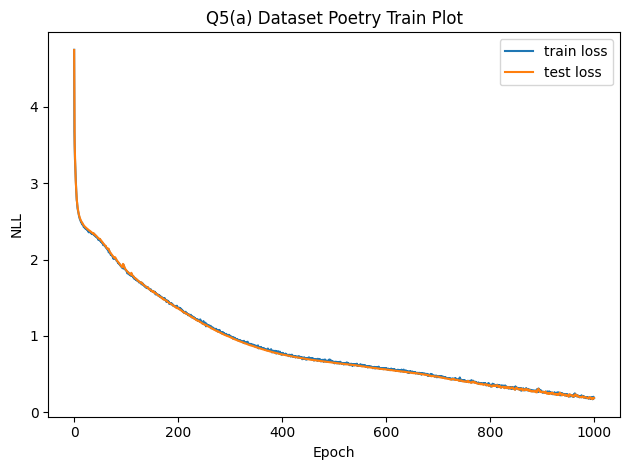

Sample 1
Basil Bunting, 30. May Frog.
che Blast Tthe fhairrought in for souls the fast make,
Thy have of the glean usetters flowerst wo

Sample 2
The fadive me a mill, night mids, my sooth,
Or hip rings of this black.
This deep-hee in darks whirers,
    Is lue by not swe

Sample 3
The doubt of future foes exiles my present joy and friend, 
Thench, we of it amch made of betped flown.
And quive cozed threec

Sample 4
Sigh no more, lyaged in the prove
The ripleadnesse of rine tmistance
That like alled in the fineous arment
Sels in thy prest 

Sample 5
The cunside Nature, before with his fleeds ..



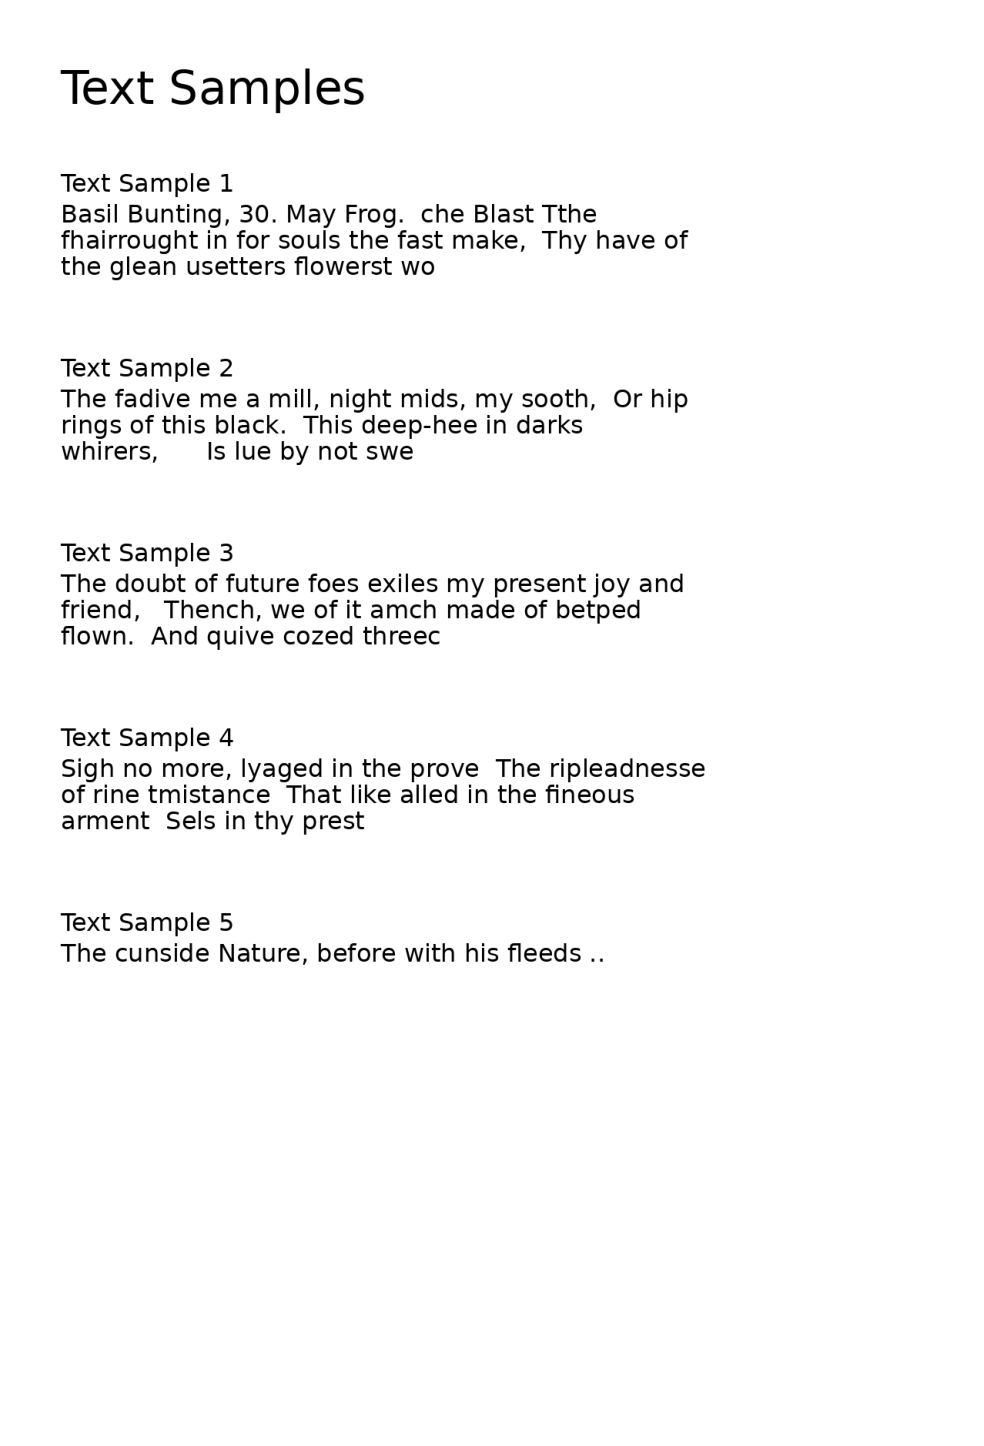

In [ ]:
torch.cuda.empty_cache()
q5a_save_results(q5_a)

# Question 6: Causal Transformer: Multimodal

So far, we have been dealing only with autoregressive generation of a single modality. Now we will train a model that operates on multiple modalities!

We will use the text labeled colored MNIST dataset, which has a text description of the MNIST image. Run the cell below to visualize the data along with the text annotation. This is the Colored MNIST v2 dataset, which also comes with these text labels.

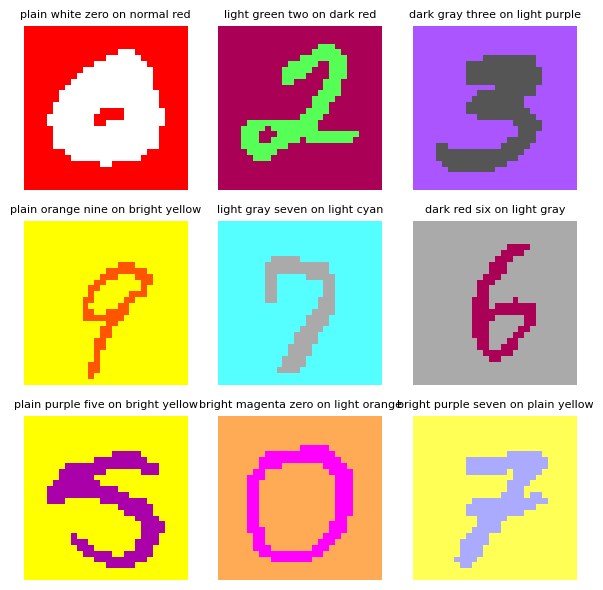

In [ ]:
visualize_q6_data()

## Part (a) Multimodal Text and Image Generation
Implement and train an autoregressive (AR) model capable of handling both text and image data. The model should be designed to process sequences composed of concatenated text and image tokens in both orders (text followed by images and images followed by text). Additionally, the model should be capable of generating unconditional text and image samples.

Data Preprocessing:
* Text Tokens: Map each unique word in the text data to a unique token. (Note that all text descriptions contain the exact same amount of words. This simplifies text processing, as you won't have to deal with sequences of different lengths as in Question 5)
* Image Tokens: Quantize the image data into tokens using the VQVAE tokenizer from Problem 4.
* In this problem, we have 2 modalities. Introduce an **\<end of text\>** token and an **\<end of image\>** token. After seeing such a token, the model should switch to sampling the next modality.
* Formulate batches as sequences of concat([**\<end of image\>**, text_tokens, **\<end of text\>**, image_tokens]) and concat([**\<end of text\>**, image_tokens, **\<end of image\>**, text_tokens]). With a 50/50 split between each ordering.

Inference:
* During inference, we cannot mix modality tokens. During sampling we can restrict the logits to only be within the relevant modality.
* After **\<end of image\>**, only allow the model to sample text tokens (including **\<end of text\>**)
* After **\<end of text\>**, only allow the model to sample image tokens (including **\<end of image\>**)
* At the very start (conditioned on the **\<bos\>** token, only allow the model to sample one of (**\<end of image\>** or **\<end of text\>**))
* As the model may not always correctly sample the **\<end of image\>** token before the image ends, you may add a rule to force the model to always sample the correct number of image tokens (49 tokens).

You can use the same hyperparameters as in 4(b) (but of course, feel free to tune your model to achieve better performance)

**You will provide these deliverables**

1. Over the course of training, record the average negative log-likelihood (nats / dim) of the training data (per minibatch) and test data (for your entire test set). Code is provided that automatically plots the training curves.
2. Report the final test set performance of your final model
3. 9 conditional samples based on provided text.
4. 9 conditional samples based on provided images.
5. 9 unconditional samples showcasing the model's capability in generating standalone text and images.

In [ ]:
def q6_a(train_data, test_data, image_shape, train_text, test_text, image_test_prompt, text_test_prompt, vqvae):
    """
    train_data: A (n_train, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    test_data: A (n_test, H, W, C) uint8 numpy array of color images with values in {0, 1, 2, 3}
    image_shape: tuple (H, W, C) The shape of the images in the dataset, indicating height, width, and number of color channels.
    train_text: list[str] Text data associated with each training image.
    test_text: list[str] Text data associated with each test image.
    image_test_prompt: (9, H, W, C) Image data used for generating conditional text samples during testing.
    text_test_prompt: list of 9 strings Text prompts used for generating conditional image samples during testing.
    vqvae: a vqvae model, trained on the relevant dataset

    Returns
    - a (# of training iterations,) numpy array of train_losses evaluated every minibatch
    - a (# of epochs + 1,) numpy array of test_losses evaluated once at initialization and after each epoch
    - a list of 9 (image, text), corresponding to the image conditioned samples
    - a list of 9 (image, text), corresponding to the text conditions samples
    - a list of 9 (image, text), corresponding to unconditional samples
    """

    # preprocessing
    train_data_toks, test_data_toks = tokenize_data_set(vqvae, train_data), tokenize_data_set(vqvae, test_data)

    preprocessor = PreprocessorMultiModal(train_text, vqvae)
    train_text_toks, test_text_toks = preprocessor.encode_text(train_text), preprocessor.encode_text(test_text)

    train_set, test_set = preprocessor.combine(train_data_toks, train_text_toks), preprocessor.combine(test_data_toks, test_text_toks)

    @dataclass
    class Config:
        num_epochs = 10
        batch_size = 32
        lr = 1e-3
        warmup_iters = 0
        min_lr = 1e-4
        lr_decay_iters = (train_data.shape[0] // batch_size) * num_epochs - warmup_iters
        dtype = torch.bfloat16

        dropout = 0.0

    lr_scheduler = CosineScheduler(
        warmup_iters=Config.warmup_iters,
        lr_decay_iters=Config.lr_decay_iters,
        base_lr=Config.lr,
        min_lr=Config.min_lr
    )


    model = Transformer(n_tokens=preprocessor.n_tokens+1, max_seq_len=57, n_heads=4, n_layers=2, d_model=128, dropout=Config.dropout)

    optimizer = optim.Adam(model.parameters(), lr=Config.lr)

    train_loader = DataLoader(train_set, Config.batch_size, shuffle=True, generator=torch.Generator(device=device),)
    test_loader = DataLoader(test_set, Config.batch_size, generator=torch.Generator(device=device))

    train_loss_history, test_loss_history = train(model, optimizer, train_loader, test_loader, num_epochs=Config.num_epochs,
                                                    lr_scheduler=lr_scheduler, clip=1.0)


    samples_text_conditioned = preprocessor.decode_multimodal(generate_image(model, text_test_prompt, preprocessor).cpu().numpy())
    samples_image_conditioned = preprocessor.decode_multimodal(generate_text(model, vqvae, image_test_prompt, preprocessor).cpu().numpy())
    samples_unconditioned = preprocessor.decode_multimodal(generate_unconditional(model, 9, preprocessor).cpu().numpy())

    return np.array(train_loss_history), np.array(test_loss_history), samples_image_conditioned, samples_text_conditioned, samples_unconditioned

### Results

Once you've implemented `q6_a`, execute the cells below to visualize and save your results



initial loss: 7.162985244117225
epoch 1: 3.008672829253224
epoch 2: 2.818260552403264
epoch 3: 2.733251476440186
epoch 4: 2.6755175582897928
epoch 5: 2.6387775264228113
epoch 6: 2.614380847150906
epoch 7: 2.5994636989630067
epoch 8: 2.587428385457292
epoch 9: 2.5868514345857663
epoch 10: 2.587224370755327
Final Test Loss: 2.5872


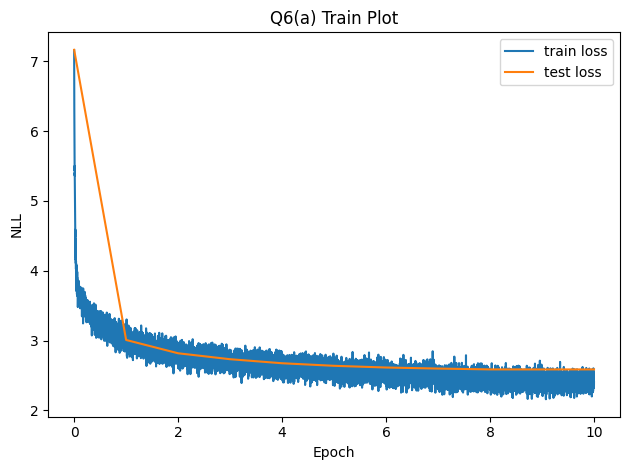

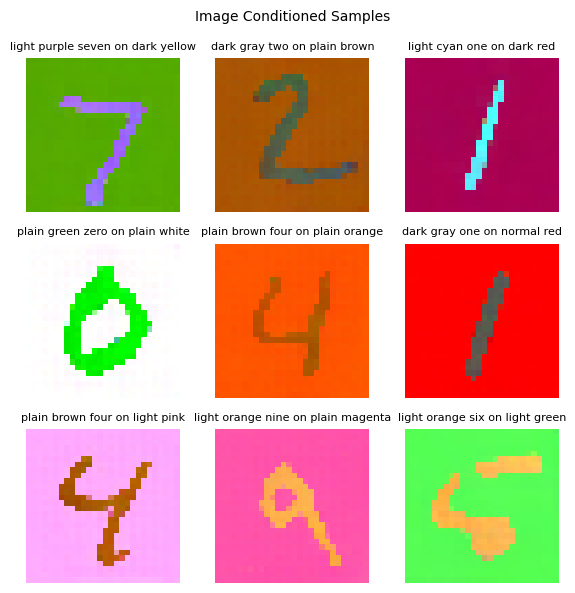

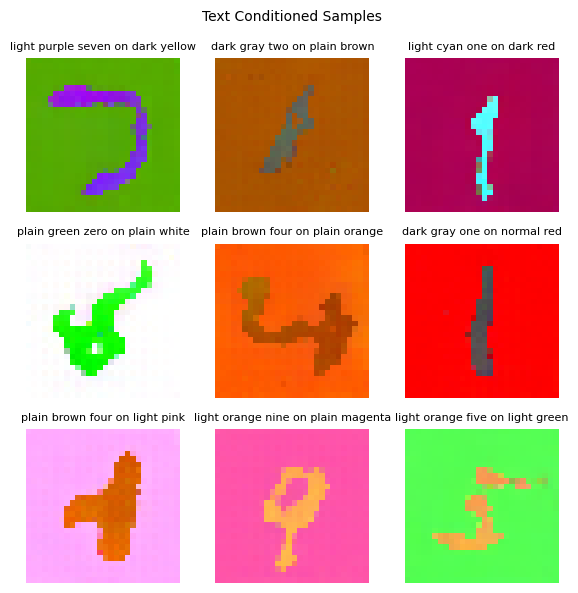

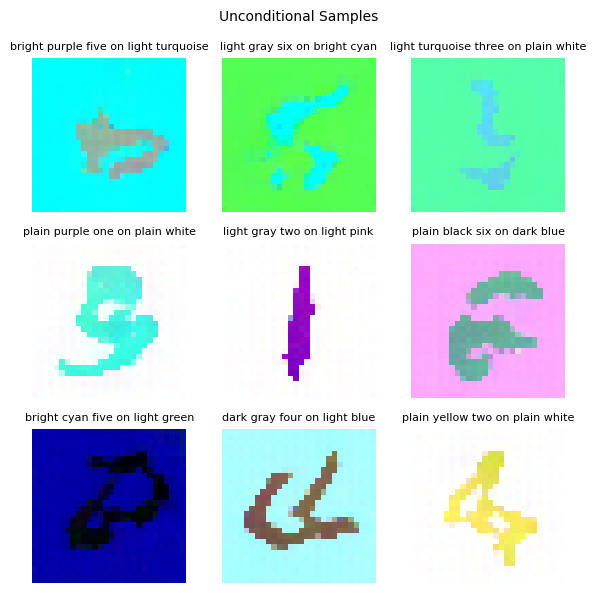

In [ ]:
# torch.cuda.empty_cache()
q6a_save_results(q6_a)